In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
class PensionLiabilityEngine:
    def __init__(self, initial_payout=100.0, wage_growth=0.05, inflation=0.04, T=30):
        """
        Projects 30-year pension liabilities for active and retired members.
        - initial_payout: Base year cash payout ($M)
        - wage_growth: Expected annual wage growth rate
        - inflation: CPI/WPI indexation rate
        - T: Projection horizon (years)
        """
        self.initial_payout = initial_payout
        self.g = wage_growth
        self.pi = inflation
        self.T = T

    def generate_cash_flows(self):
        time_steps = np.arange(1, self.T + 1)
        # Net growth rate combining inflation indexation and salary progression
        effective_growth = (1 + self.g) * (1 + self.pi) - 1
        cash_flows = self.initial_payout * ((1 + effective_growth) ** time_steps)
        return time_steps, cash_flows

    def present_value_and_duration(self, discount_rate=0.072):
        time_steps, cash_flows = self.generate_cash_flows()
        discount_factors = (1 + discount_rate) ** time_steps
        pv_cash_flows = cash_flows / discount_factors
        total_pv = np.sum(pv_cash_flows)

        # Macaulay Duration & Modified Duration
        macaulay_duration = np.sum(time_steps * pv_cash_flows) / total_pv
        modified_duration = macaulay_duration / (1 + discount_rate)

        return total_pv, macaulay_duration, modified_duration


--- ACTUARIAL LIABILITY PROFILE ---
Present Value of Liabilities (PV_L): $4046.67 Million
Macaulay Duration: 16.88 Years
Modified Duration: 15.74 Years


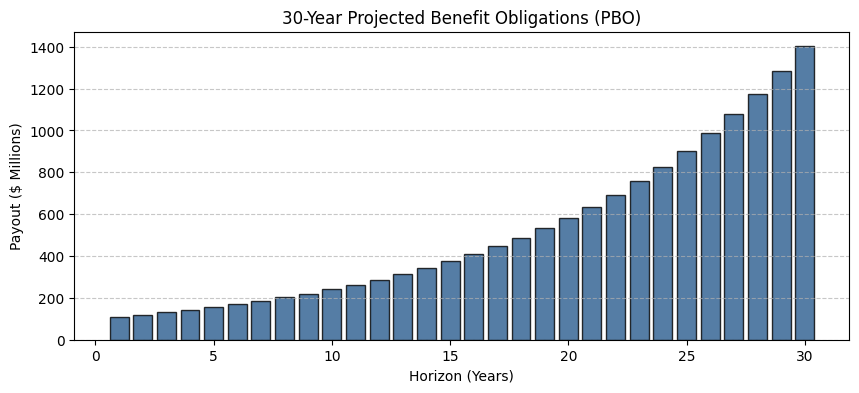

In [3]:
engine = PensionLiabilityEngine(initial_payout=100.0, wage_growth=0.05, inflation=0.04, T=30)
times, cfs = engine.generate_cash_flows()
pv_L, mac_D, mod_D = engine.present_value_and_duration(discount_rate=0.072)

print(f"--- ACTUARIAL LIABILITY PROFILE ---")
print(f"Present Value of Liabilities (PV_L): ${pv_L:.2f} Million")
print(f"Macaulay Duration: {mac_D:.2f} Years")
print(f"Modified Duration: {mod_D:.2f} Years")

plt.figure(figsize=(10, 4))
plt.bar(times, cfs, color='#2b5c8f', alpha=0.8, edgecolor='black')
plt.title('30-Year Projected Benefit Obligations (PBO)')
plt.xlabel('Horizon (Years)')
plt.ylabel('Payout ($ Millions)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()